# Student career success & placement prediction

### Data Overview

In [3]:
import pandas as pd
df = pd.read_csv("student_career_success_dataset.csv")

In [4]:
df

,Student_ID,Age,Gender,University_Year,Major,Attendance_Percentage,Study_Hours_Per_Week,CGPA,Academic_Performance,Programming_Skill,...,Teamwork,Problem_Solving,English_Proficiency,Interview_Score,Employability_Score,Placement_Status,Company_Tier,Career_Field,Placement_Mode,Starting_Salary_USD
0,ST000001,22,Male,Sophomore,Computer Science,86,21,3.28,Good,9,...,7,8,Advanced,72,231.70,Placed,Tier 1,Backend Developer,Campus Placement,72082
1,ST000002,20,Female,Freshman,Computer Science,64,18,2.53,Poor,6,...,6,5,Basic,59,157.45,Not Placed,No Company,Not Placed,Not Applicable,0
2,ST000003,23,Male,Senior,Information Technology,75,19,2.83,Average,8,...,8,7,Advanced,76,203.45,Placed,Tier 1,IT Support Engineer,Campus Placement,94898
3,ST000004,23,Female,Senior,Information Technology,80,19,2.80,Average,5,...,6,6,Intermediate,67,171.50,Not Placed,No Company,Not Placed,Not Applicable,0
4,ST000005,23,Female,Senior,Software Engineering,73,19,2.93,Average,9,...,8,9,Advanced,82,225.45,Placed,Tier 1,Software Engineer,Internship Conversion,85256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,ST049996,22,Male,Sophomore,Software Engineering,76,13,2.92,Average,9,...,5,8,Advanced,86,224.80,Placed,Tier 1,Software Engineer,Campus Placement,103525
49996,ST049997,21,Male,Senior,Artificial Intelligence,84,21,2.90,Average,7,...,9,7,Intermediate,69,190.70,Not Placed,No Company,Not Placed,Not Applicable,0
49997,ST049998,20,Female,Junior,Software Engineering,86,25,3.31,Good,9,...,6,9,Advanced,86,243.15,Placed,Tier 1,DevOps Engineer,Campus Placement,102324
49998,ST049999,20,Male,Junior,Software Engineering,92,15,3.05,Average,10,...,6,10,Advanced,87,245.25,Placed,Tier 1,DevOps Engineer,Referral,82095


In [5]:
df.shape

(50000, 29)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             50000 non-null  object 
 1   Age                    50000 non-null  int64  
 2   Gender                 50000 non-null  object 
 3   University_Year        50000 non-null  object 
 4   Major                  50000 non-null  object 
 5   Attendance_Percentage  50000 non-null  int64  
 6   Study_Hours_Per_Week   50000 non-null  int64  
 7   CGPA                   50000 non-null  float64
 8   Academic_Performance   50000 non-null  object 
 9   Programming_Skill      50000 non-null  int64  
 10  Projects_Completed     50000 non-null  int64  
 11  Certifications         50000 non-null  int64  
 12  Hackathons             50000 non-null  int64  
 13  GitHub_Profile         50000 non-null  object 
 14  Internships            50000 non-null  int64  
 15  Le

In [7]:
df.isna().sum()

,0
Student_ID,0
Age,0
Gender,0
University_Year,0
Major,0
Attendance_Percentage,0
Study_Hours_Per_Week,0
CGPA,0
Academic_Performance,0
Programming_Skill,0


In [8]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'University_Year', 'Major',
       'Attendance_Percentage', 'Study_Hours_Per_Week', 'CGPA',
       'Academic_Performance', 'Programming_Skill', 'Projects_Completed',
       'Certifications', 'Hackathons', 'GitHub_Profile', 'Internships',
       'Leadership_Experience', 'LinkedIn_Profile', 'Resume_Score',
       'Communication_Skills', 'Teamwork', 'Problem_Solving',
       'English_Proficiency', 'Interview_Score', 'Employability_Score',
       'Placement_Status', 'Company_Tier', 'Career_Field', 'Placement_Mode',
       'Starting_Salary_USD'],
      dtype='object')

### Exploratory Data Analysis

In [9]:
df["Placement_Status"].value_counts()

,count
Placement_Status,
Placed,39040
Not Placed,10960


In [10]:
df["Placement_Status"].value_counts(normalize=True)

,proportion
Placement_Status,
Placed,0.7808
Not Placed,0.2192


Text(0, 0.5, 'Number of Students')

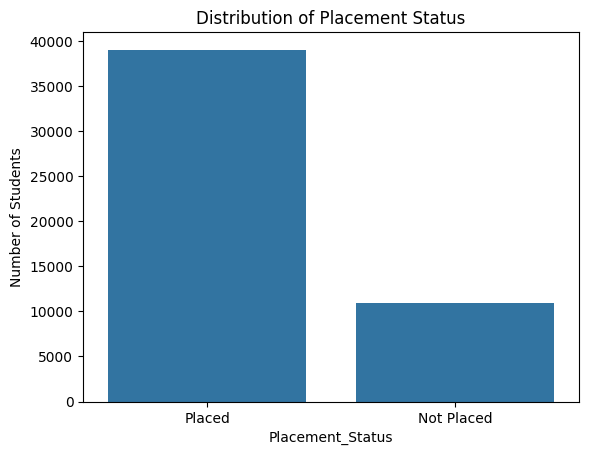

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="Placement_Status")
plt.title("Distribution of Placement Status")
plt.ylabel("Number of Students")

Placement Status is imbalanced, with the majority of observations belonging to the Placed class (78.08%)

### Correlation Analysis

In [12]:
numeric_df = df.select_dtypes(include="number")

corr = numeric_df.corr()
corr

,Age,Attendance_Percentage,Study_Hours_Per_Week,CGPA,Programming_Skill,Projects_Completed,Certifications,Hackathons,Internships,Resume_Score,Communication_Skills,Teamwork,Problem_Solving,Interview_Score,Employability_Score,Starting_Salary_USD
Age,1.000000,0.002119,-0.001698,-0.000976,0.008679,0.010230,-0.006526,0.003476,0.004827,0.005767,0.002272,0.007132,0.001245,0.008255,0.006908,0.002034
Attendance_Percentage,0.002119,1.000000,-0.002376,0.667727,0.253053,0.159540,0.116256,0.113290,0.300283,0.224345,0.154020,0.071011,0.371952,0.266755,0.403592,0.200322
Study_Hours_Per_Week,-0.001698,-0.002376,1.000000,0.533161,0.200839,0.118428,0.095808,0.088229,0.232557,0.166050,0.112742,0.050155,0.299398,0.213467,0.317465,0.152227
CGPA,-0.000976,0.667727,0.533161,1.000000,0.379843,0.231492,0.176689,0.168589,0.445446,0.323818,0.223603,0.100466,0.560389,0.399674,0.601362,0.292368
Programming_Skill,0.008679,0.253053,0.200839,0.379843,1.000000,0.601406,0.070893,0.438893,0.462807,0.601535,0.283528,0.263677,0.736964,0.651221,0.814310,0.403995
Projects_Completed,0.010230,0.159540,0.118428,0.231492,0.601406,1.000000,0.039354,0.262996,0.627914,0.651236,0.371687,0.210937,0.443158,0.533144,0.752465,0.375275
Certifications,-0.006526,0.116256,0.095808,0.176689,0.070893,0.039354,1.000000,0.029577,0.078540,0.178882,0.037708,0.012655,0.098983,0.088693,0.194933,0.091470
Hackathons,0.003476,0.113290,0.088229,0.168589,0.438893,0.262996,0.029577,1.000000,0.201162,0.269416,0.176589,0.498170,0.323848,0.294212,0.364893,0.184656
Internships,0.004827,0.300283,0.232557,0.445446,0.462807,0.627914,0.078540,0.201162,1.000000,0.696083,0.508538,0.158430,0.429653,0.593748,0.789657,0.429836
Resume_Score,0.005767,0.224345,0.166050,0.323818,0.601535,0.651236,0.178882,0.269416,0.696083,1.000000,0.459157,0.254435,0.480983,0.628506,0.790519,0.475977


<Axes: >

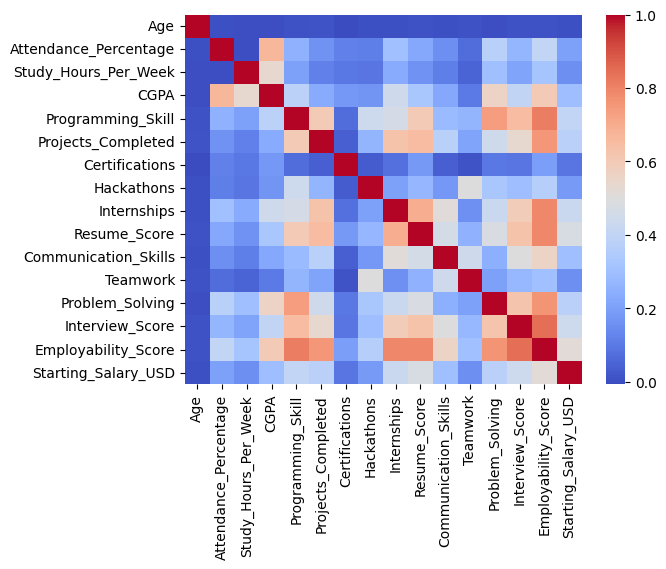

In [13]:
import seaborn as sns
sns.heatmap(corr,cmap="coolwarm")

Convert placement status into binary target

In [14]:
df["Placement_Target"] = df["Placement_Status"].map({
    "Not Placed": 0,
    "Placed": 1 })

In [15]:
df[["Placement_Target", "Placement_Status"]].head()

,Placement_Target,Placement_Status
0,1,Placed
1,0,Not Placed
2,1,Placed
3,0,Not Placed
4,1,Placed


Correlation of numeric features with target

In [16]:
numeric_features = df.select_dtypes(include="number").drop(columns=["Starting_Salary_USD", "Placement_Target"])

corr_with_target = numeric_features.corrwith(df["Placement_Target"]).sort_values(ascending=False)

print(corr_with_target)

Employability_Score      0.472687
Resume_Score             0.425195
Interview_Score          0.402386
Internships              0.392040
Programming_Skill        0.370803
Problem_Solving          0.348187
Projects_Completed       0.344400
Communication_Skills     0.275114
CGPA                     0.270335
Attendance_Percentage    0.184865
Hackathons               0.169405
Study_Hours_Per_Week     0.141672
Teamwork                 0.140716
Certifications           0.084712
Age                      0.000412
dtype: float64


Select the top 5 most correlated numeric features

In [17]:
features = ["Employability_Score", "Resume_Score", "Interview_Score", "Internships", "Programming_Skill"]

### Data preparation

In [18]:
X = df[features]
y = df["Placement_Target"]

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [20]:
df['Employability_Score'].describe()

,Employability_Score
count,50000.000000
mean,213.991394
std,26.824224
min,82.300000
25%,197.350000
50%,217.250000
75%,233.600000
max,279.050000


In [21]:
X_train[:5]

,Employability_Score,Resume_Score,Interview_Score,Internships,Programming_Skill
999,150.50,67,54,2,4
40153,204.55,100,60,4,7
10686,168.30,75,68,2,5
49018,179.35,84,68,2,6
42496,198.35,97,68,4,6


In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

How scaler works under the hood

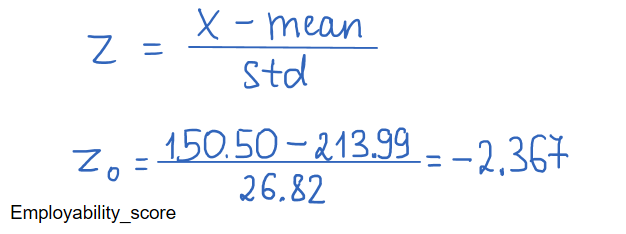

In [23]:
X_train_scaled[:5]

array([[-2.37065433, -3.96044686, -1.87478557, -2.03699211, -2.08808477],
       [-0.354406  ,  0.53918549, -1.39723763, -0.04842169, -0.09395667],
       [-1.70665396, -2.8696269 , -0.76050704, -2.03699211, -1.42337541],
       [-1.29445148, -1.64245444, -0.76050704, -2.03699211, -0.75866604],
       [-0.58568703,  0.130128  , -0.76050704, -0.04842169, -0.75866604]])

## Model 1 - Top 5 features

In [24]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [25]:
y_pred = model.predict(X_test_scaled)

### Model evaluation

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

Accuracy: 0.8187
Precision: 0.8415176028255669
Recall: 0.945952868852459
F1: 0.8906843533313235


In [27]:
model.coef_

array([[ 1.27639316, -0.01568017,  0.01311642,  0.03359395,  0.01135557]])

In [28]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[ 801, 1391],
       [ 422, 7386]])

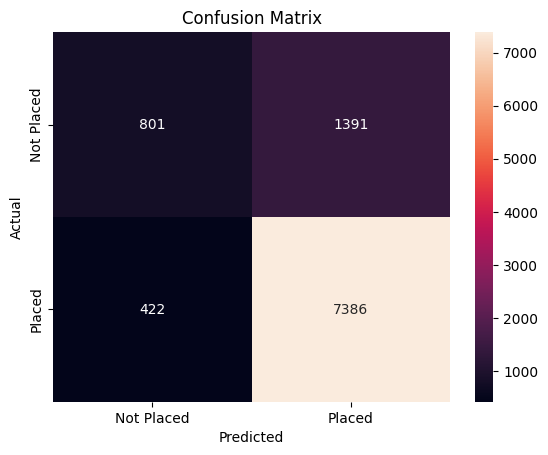

In [29]:
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', xticklabels=["Not Placed", "Placed"], yticklabels=["Not Placed", "Placed"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [30]:
fp_mask = (y_test == 0) & (y_pred == 1)

In [31]:
fp_students = X_test[fp_mask]
fp_students

,Employability_Score,Resume_Score,Interview_Score,Internships,Programming_Skill
1149,209.80,100,81,5,5
32893,205.95,100,73,4,8
42710,202.45,92,73,4,6
4022,190.35,100,63,4,6
29894,215.85,97,82,4,8
...,...,...,...,...,...
6861,197.45,100,61,3,6
28565,228.30,100,83,5,9
49030,195.05,100,76,4,6
17029,198.15,100,60,3,7


Students misclassified as placed (false positives)

In [32]:
fp_students = df.loc[X_test.index[fp_mask]]

print(fp_students.head())

      Student_ID  Age Gender University_Year                    Major  \
1149    ST001150   19   Male          Senior            Cybersecurity   
32893   ST032894   23   Male          Senior  Artificial Intelligence   
42710   ST042711   21   Male          Senior         Computer Science   
4022    ST004023   19   Male          Junior             Data Science   
29894   ST029895   19   Male          Senior   Information Technology   

       Attendance_Percentage  Study_Hours_Per_Week  CGPA Academic_Performance  \
1149                      83                    23  2.92              Average   
32893                     76                    15  2.63              Average   
42710                     75                    20  3.19              Average   
4022                      89                    21  2.89              Average   
29894                     90                    23  3.35                 Good   

       Programming_Skill  ...  Problem_Solving  English_Proficiency  \
114

In [33]:
df.loc[X_test.index[fp_mask], features].mean()

,0
Employability_Score,206.836161
Resume_Score,96.168224
Interview_Score,74.769950
Internships,3.854062
Programming_Skill,6.771387


In [34]:
fn_mask = (y_test == 1) & (y_pred == 0)
df.loc[X_test.index[fn_mask], features].mean()

,0
Employability_Score,167.741469
Resume_Score,82.746445
Interview_Score,58.812796
Internships,2.639810
Programming_Skill,5.087678


In [35]:
tp_mask = (y_test == 1) & (y_pred == 1)
df.loc[X_test.index[tp_mask], features].mean()

,0
Employability_Score,223.328920
Resume_Score,98.493772
Interview_Score,81.206607
Internships,4.348768
Programming_Skill,7.538722


## Model 2 - All Numerical Features


### 1. Define features and target

In [36]:
numeric_features = [
    "Age",
    "Attendance_Percentage",
    "Study_Hours_Per_Week",
    "CGPA",
    "Programming_Skill",
    "Projects_Completed",
    "Certifications",
    "Hackathons",
    "Internships",
    "Resume_Score",
    "Communication_Skills",
    "Teamwork",
    "Problem_Solving",
    "Interview_Score",
    "Employability_Score"
]

In [37]:
X2 = df[numeric_features]
y = df['Placement_Target']

### 2. Train-test split

In [38]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2,y, test_size=0.2, random_state=42, stratify=y)

### 3. Feature scaling

In [39]:
scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

### 4. Model training

In [40]:
from sklearn.linear_model import LogisticRegression
model2 = LogisticRegression()
model2.fit(X2_train_scaled, y2_train)

LogisticRegression()

In [41]:
y_pred2 = model2.predict(X2_test_scaled)

### 6. Model evaluation

In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy2 = accuracy_score(y2_test, y_pred2)
precision2 = precision_score(y2_test, y_pred2)
recall2 = recall_score(y2_test, y_pred2)
f1_2 = f1_score(y2_test, y_pred2)

print("Accuracy:", accuracy2)
print("Precision:", precision2)
print("Recall:", recall2)
print("F1:", f1_2)

Accuracy: 0.8182
Precision: 0.8415830291970803
Recall: 0.9450563524590164
F1: 0.890323359073359


In [43]:
model2.coef_

array([[-0.01111273,  0.00878701,  0.01510855,  0.15011823,  0.24241025,
         0.17835386,  0.07160727,  0.00329995,  0.2225946 ,  0.07345635,
         0.12366109, -0.00586556,  0.13498393,  0.24543909,  0.25253139]])

## Model 3 - Numerical and Categorical Features


### Data preparation

In [44]:
df.select_dtypes(include="object").columns

Index(['Student_ID', 'Gender', 'University_Year', 'Major',
       'Academic_Performance', 'GitHub_Profile', 'Leadership_Experience',
       'LinkedIn_Profile', 'English_Proficiency', 'Placement_Status',
       'Company_Tier', 'Career_Field', 'Placement_Mode'],
      dtype='object')

In [45]:
categorical_features = [
    "Gender",
    "University_Year",
    "Major",
    "Academic_Performance",
    "GitHub_Profile",
    "Leadership_Experience",
    "LinkedIn_Profile",
    "English_Proficiency"
]

In [46]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [47]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [48]:
X3 = df[numeric_features + categorical_features]
y = df["Placement_Target"]

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y, test_size=0.2, random_state=42, stratify=y)
X3_train_transformed = preprocessor.fit_transform(X3_train)
X3_test_transformed = preprocessor.transform(X3_test)

### Model Training

In [68]:
model3 = LogisticRegression(max_iter=1000)
model3.fit(X3_train_transformed, y3_train)
y_pred3 = model3.predict(X3_test_transformed)

### Model evaluation

In [69]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy3 = accuracy_score(y3_test, y_pred3)
precision3 = precision_score(y3_test, y_pred3)
recall3 = recall_score(y3_test, y_pred3)
f1_3 = f1_score(y3_test, y_pred3)

print("Accuracy:", accuracy3)
print("Precision:", precision3)
print("Recall:", recall3)
print("F1:", f1_3)

Accuracy: 0.8189
Precision: 0.8417873019491622
Recall: 0.9458247950819673
F1: 0.8907786020143538


In [51]:
model3.coef_

array([[-0.011452  ,  0.00554125,  0.0137938 ,  0.16561581,  0.22998847,
         0.18136623,  0.07156776,  0.00431917,  0.22134755,  0.07119021,
         0.12259345, -0.0050713 ,  0.13555988,  0.24657172,  0.25262933,
         0.14378082,  0.15635163,  0.11240033,  0.1438565 ,  0.0724173 ,
         0.10435866,  0.09190032,  0.04671424, -0.01227118,  0.03011373,
         0.05487143,  0.13176438,  0.08030784,  0.01599384,  0.0650385 ,
         0.15308325, -0.12477658,  0.16928701,  0.21493909,  0.20761783,
         0.20491495,  0.20918364,  0.20334914,  0.19861561,  0.21391717,
         0.14691884,  0.1279774 ,  0.13763654]])

## Model Comparison

In [52]:
results = pd.DataFrame({
    "Model": ["Model 1", "Model 2", "Model 3"],
    "Accuracy": [accuracy, accuracy2, accuracy3],
    "Precision": [precision, precision2, precision3],
    "Recall": [recall, recall2, recall3],
    "F1": [f1, f1_2, f1_3]
})

results

,Model,Accuracy,Precision,Recall,F1
0,Model 1,0.8187,0.841518,0.945953,0.890684
1,Model 2,0.8182,0.841583,0.945056,0.890323
2,Model 3,0.8189,0.841787,0.945825,0.890779


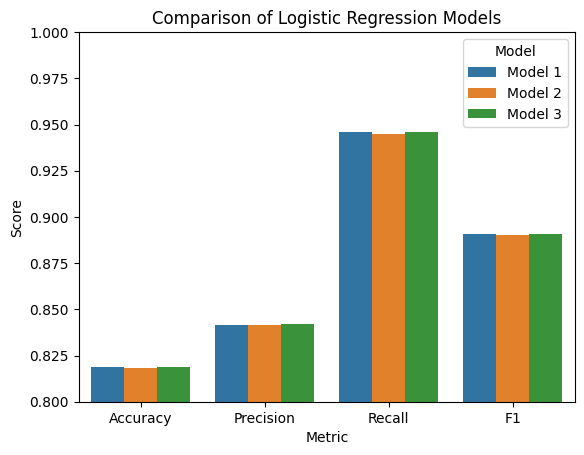

In [53]:
import matplotlib.pyplot as plt

results_melted = results.melt(id_vars="Model", var_name="Metric", value_name="Score")

sns.barplot(data=results_melted, x="Metric", y="Score", hue="Model")

plt.ylim(0.8, 1)
plt.title("Comparison of Logistic Regression Models")
plt.show()

## Feature Coefficients

In [54]:
feature_names = preprocessor.get_feature_names_out()

print(feature_names)

['num__Age' 'num__Attendance_Percentage' 'num__Study_Hours_Per_Week'
 'num__CGPA' 'num__Programming_Skill' 'num__Projects_Completed'
 'num__Certifications' 'num__Hackathons' 'num__Internships'
 'num__Resume_Score' 'num__Communication_Skills' 'num__Teamwork'
 'num__Problem_Solving' 'num__Interview_Score' 'num__Employability_Score'
 'cat__Gender_Female' 'cat__Gender_Male' 'cat__Gender_Other'
 'cat__University_Year_Freshman' 'cat__University_Year_Junior'
 'cat__University_Year_Senior' 'cat__University_Year_Sophomore'
 'cat__Major_Artificial Intelligence' 'cat__Major_Business Analytics'
 'cat__Major_Computer Science' 'cat__Major_Cybersecurity'
 'cat__Major_Data Science' 'cat__Major_Electrical Engineering'
 'cat__Major_Information Technology' 'cat__Major_Software Engineering'
 'cat__Academic_Performance_Average' 'cat__Academic_Performance_Excellent'
 'cat__Academic_Performance_Good' 'cat__Academic_Performance_Poor'
 'cat__GitHub_Profile_No' 'cat__GitHub_Profile_Yes'
 'cat__Leadership_Experi

In [55]:
coefficients = model3.coef_[0]
coefficients

array([-0.011452  ,  0.00554125,  0.0137938 ,  0.16561581,  0.22998847,
        0.18136623,  0.07156776,  0.00431917,  0.22134755,  0.07119021,
        0.12259345, -0.0050713 ,  0.13555988,  0.24657172,  0.25262933,
        0.14378082,  0.15635163,  0.11240033,  0.1438565 ,  0.0724173 ,
        0.10435866,  0.09190032,  0.04671424, -0.01227118,  0.03011373,
        0.05487143,  0.13176438,  0.08030784,  0.01599384,  0.0650385 ,
        0.15308325, -0.12477658,  0.16928701,  0.21493909,  0.20761783,
        0.20491495,  0.20918364,  0.20334914,  0.19861561,  0.21391717,
        0.14691884,  0.1279774 ,  0.13763654])

In [56]:
coef_df = pd.DataFrame({
    "Feature":feature_names,
    "Coefficient":coefficients
}
)
coef_df

,Feature,Coefficient
0,num__Age,-0.011452
1,num__Attendance_Percentage,0.005541
2,num__Study_Hours_Per_Week,0.013794
3,num__CGPA,0.165616
4,num__Programming_Skill,0.229988
5,num__Projects_Completed,0.181366
6,num__Certifications,0.071568
7,num__Hackathons,0.004319
8,num__Internships,0.221348
9,num__Resume_Score,0.071190


In [57]:
top_positive = coef_df.nlargest(5, "Coefficient")
top_negative = coef_df.nsmallest(5, "Coefficient")
top_features = pd.concat([top_negative, top_positive]).sort_values("Coefficient", ascending=False)
top_features

,Feature,Coefficient
14,num__Employability_Score,0.252629
13,num__Interview_Score,0.246572
4,num__Programming_Skill,0.229988
8,num__Internships,0.221348
33,cat__Academic_Performance_Poor,0.214939
7,num__Hackathons,0.004319
11,num__Teamwork,-0.005071
0,num__Age,-0.011452
23,cat__Major_Business Analytics,-0.012271
31,cat__Academic_Performance_Excellent,-0.124777


## Top 10 most influential features

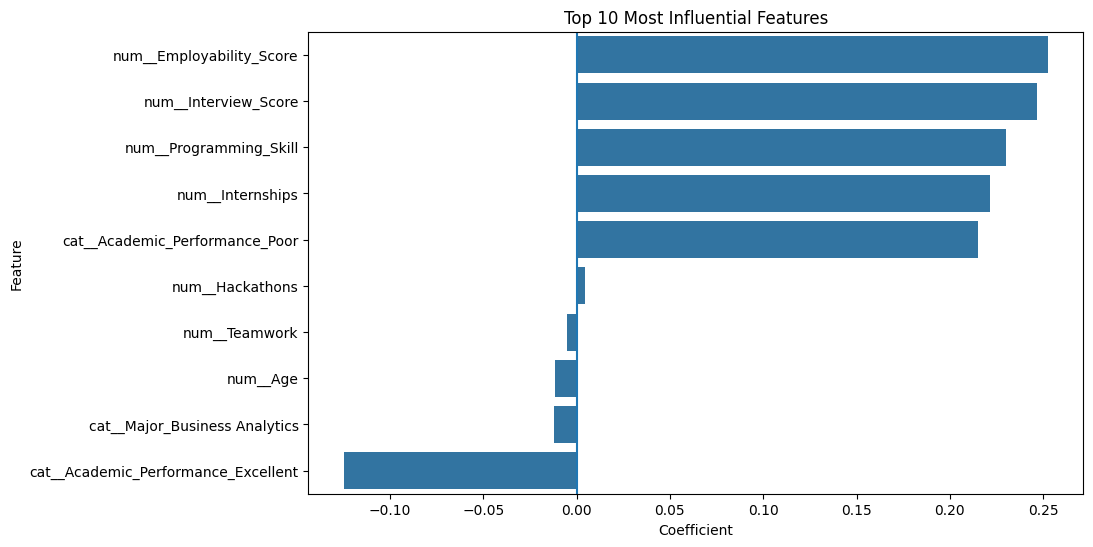

In [58]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x="Coefficient", y="Feature")

plt.title("Top 10 Most Influential Features")
plt.axvline(0)

## Conclusion

*   **Model 3 (numerical + categorical features) showed the best overall performance.** However, the difference between the three models was very small, suggesting that adding more features did not significantly improve the results.
*   **Employability Score and Interview Score** had the strongest influence on the model's predictions.

Overall, this project helped me explore the complete basic machine learning workflow: data exploration, preprocessing, feature selection, training multiple models, and evaluating their performance.



---



## Salary Prediction - Linear Regression

In [59]:
df.groupby("Placement_Status")["Starting_Salary_USD"].describe()

,count,mean,std,min,25%,50%,75%,max
Placement_Status,,,,,,,,
Not Placed,10960.0,0.000000,0.000000,0.0,0.00,0.0,0.0,0.0
Placed,39040.0,88355.747285,13608.503361,25096.0,78501.75,89025.0,99531.0,110000.0


#### drop Not Placed students from dataset

In [60]:
placed_df = df[df["Placement_Status"] == "Placed"].copy()

In [61]:
placed_df.shape

(39040, 30)

In [62]:
y = placed_df["Starting_Salary_USD"]

In [66]:
X4 = placed_df.drop(columns=["Starting_Salary_USD", "Student_ID", "Placement_Status"])

In [64]:
y.describe()

,Starting_Salary_USD
count,39040.000000
mean,88355.747285
std,13608.503361
min,25096.000000
25%,78501.750000
50%,89025.000000
75%,99531.000000
max,110000.000000


In [67]:
X4.columns

Index(['Age', 'Gender', 'University_Year', 'Major', 'Attendance_Percentage',
       'Study_Hours_Per_Week', 'CGPA', 'Academic_Performance',
       'Programming_Skill', 'Projects_Completed', 'Certifications',
       'Hackathons', 'GitHub_Profile', 'Internships', 'Leadership_Experience',
       'LinkedIn_Profile', 'Resume_Score', 'Communication_Skills', 'Teamwork',
       'Problem_Solving', 'English_Proficiency', 'Interview_Score',
       'Employability_Score', 'Company_Tier', 'Career_Field', 'Placement_Mode',
       'Placement_Target'],
      dtype='object')

In [70]:
X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y, test_size=0.2, random_state=42)
X4_train_transformed = preprocessor.fit_transform(X4_train)
X4_test_transformed = preprocessor.transform(X4_test)

from sklearn.linear_model import LinearRegression
model4 = LinearRegression()
model4.fit(X4_train_transformed, y4_train)
y_pred4 = model4.predict(X4_test_transformed)

In [76]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
mae = mean_absolute_error(y4_test, y_pred4)
mse = mean_squared_error(y4_test, y_pred4)
rmse = mse ** 0.5
r2 = r2_score(y4_test, y_pred4)
print(f"Mae = {mae}")
print(f"Mse = {mse}")
print(f"Rmse = {rmse}")
print(f"R2 = {r2}")

Mae = 10627.283979225913
Mse = 156891778.2104433
Rmse = 12525.644822141625
R2 = 0.13935025399909906


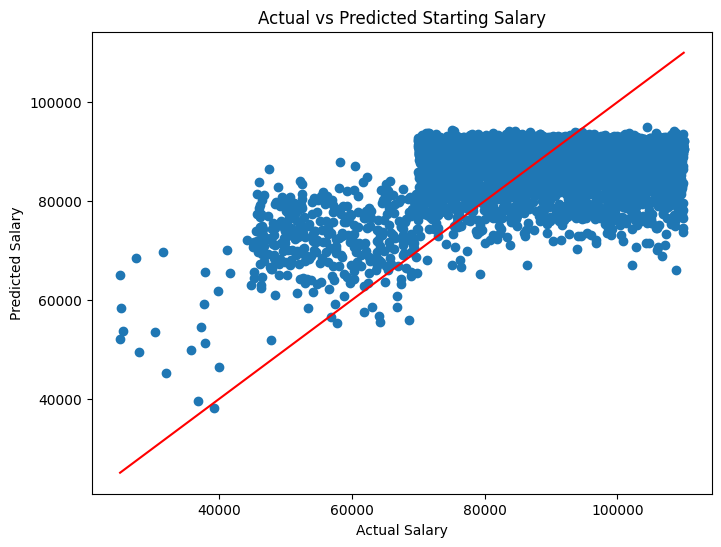

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y4_test, y_pred4)
plt.plot(
    [y4_test.min(), y4_test.max()],
    [y4_test.min(), y4_test.max()], color='r'
)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")

plt.title("Actual vs Predicted Starting Salary")

plt.show()

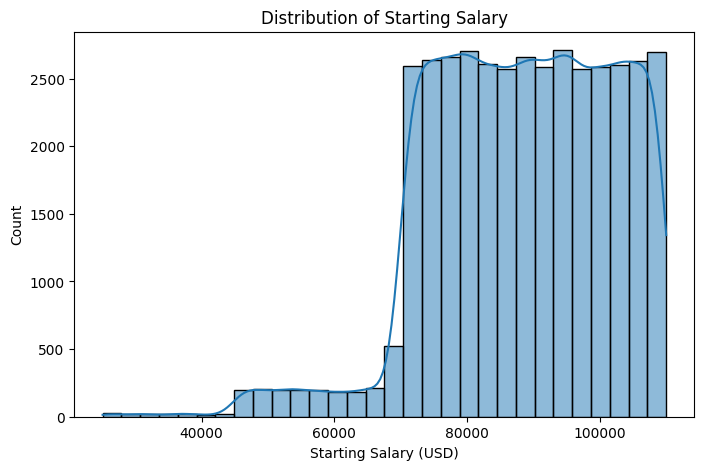

In [77]:
plt.figure(figsize=(8, 5))

sns.histplot(y, bins=30, kde=True)

plt.title("Distribution of Starting Salary")
plt.xlabel("Starting Salary (USD)")
plt.show()

### Conclusion

Linear Regression did not perform well for predicting starting salaries in this dataset. The model achieved an R² of 0.14, meaning that it explained only a small part of the variation in salaries. The MAE was \$10,627 and the RMSE was \$12,526.

This result suggests that a different model may be more suitable for this task.